# Coleman Coalitions — Paper Examples

This notebook reproduces all nine worked examples from the draft manuscript
**"Coalition paper — draft manus summer 2019"**.

The examples build progressively in complexity:

| # | Actors | Issue | Key finding |
|---|--------|-------|-------------|
| 1 | 3 | Fully aligned, equal control | No gain from coalitions |
| 2 | 3 | Conflicting attitudes | Any two-actor coalition beats the grand coalition; first movers win |
| 3 | 3 | Asymmetric attitudes | The pair agreeing on most issues wins (A+C) |
| 4 | 3 | Skewed interest intensity | Intensity can override alignment (B+C wins) |
| 5 | 4 | Randomly generated | Cyclic loop — no stable coalition |
| 6 | 4 | Same + new issue | Loop broken by adding one issue where B, C, D agree |
| 7 | 4 | Randomly generated | Two stable sinks — outcome depends on starting point |
| 8 | 5 | 1 000 MC sims | Min-winning coalition (C+D) wins only ~35% of the time |
| 9 | 4 | 1 000 MC sims | Varying control: A+B or B+D dominate depending on draw |

---
**Key concepts**  
- **Control matrix** $c_{ki}$: fraction of resource $k$ controlled by actor $i$ (rows sum to 1)  
- **Directed interest** $y_{ij}$: signed interest of actor $i$ in event $j$ (rows sum to 1 by absolute value)  
- **Coalition value**: expected interest-satisfaction for each actor given the coalition's collective vote-trading outcome  
- **Winning (sink) coalition**: no member can improve by joining a different coalition

In [1]:
from __future__ import annotations
import ast, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import coleman_coalitions as cc
from coleman_coalitions.solver import SolverConvergenceError

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

RNG = np.random.default_rng(42)

In [2]:
# ── Helper functions ─────────────────────────────────────────────────────────

def make_inputs(directed_issues_actors, c_issues_actors):
    """Build inputs from paper-style matrices (issues × actors)."""
    y_ia = np.array(directed_issues_actors, dtype=float)   # (q, n)
    c_ia = np.array(c_issues_actors, dtype=float)          # (q, n)
    q, n = y_ia.shape
    inputs = cc.setup(n, q, q, y_ia.T, np.eye(q), c_ia)
    cc.check_parameters(inputs)
    return inputs

def run(inputs):
    """Full analysis → coalition analysis.  Returns (coalition_outputs, summary, TPM)."""
    cc.run_full_analysis(inputs)
    coalitions = cc.feasible_coalitions(inputs)
    co = cc.coalition_trad(inputs, coalitions)
    summary, TPM = cc.optimal_coalition(co)
    return co, summary, TPM

def winner_labels(co, TPM, actor_names):
    winning = cc.winning_coalitions(TPM)
    return [
        '+'.join(actor_names[i] for i in ast.literal_eval(k))
        for k, w in zip(co.keys(), winning) if w
    ]

def uniform_ctrl(q, n):
    return [[1/n]*n for _ in range(q)]

---
## Example 1 — No conflict, no gain

Three actors (A, B, C) have **equal control** over three issues, **identical positive attitudes**, and **equal interest weights**.  
Because everyone wants the same outcomes with equal force, the coalition that forms makes no difference — all produce identical results.

> *Conclusion*: When attitudes are aligned and control is equal, coalitions are unnecessary.

In [3]:
# All directed interests = +1/3 (positive attitude, equal weight)
d1 = [[1/3, 1/3, 1/3],
      [1/3, 1/3, 1/3],
      [1/3, 1/3, 1/3]]

inputs1 = make_inputs(d1, uniform_ctrl(3, 3))
co1, sm1, TPM1 = run(inputs1)

print("Winning coalitions:", winner_labels(co1, TPM1, list('ABC')) or "none (all equal)")

Winning coalitions: none (all equal)


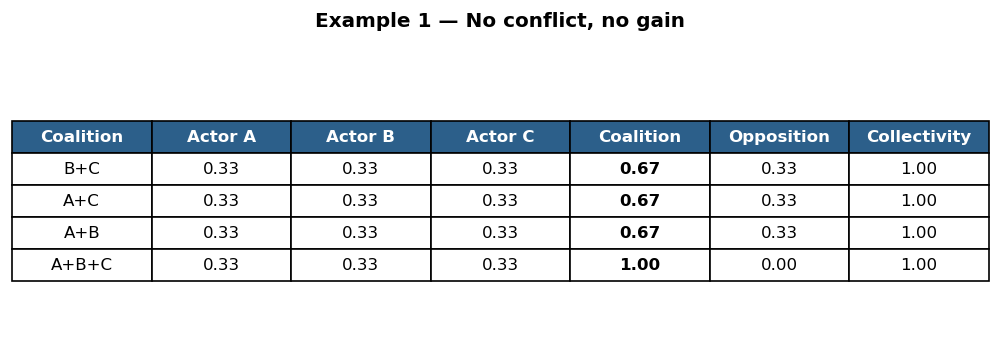

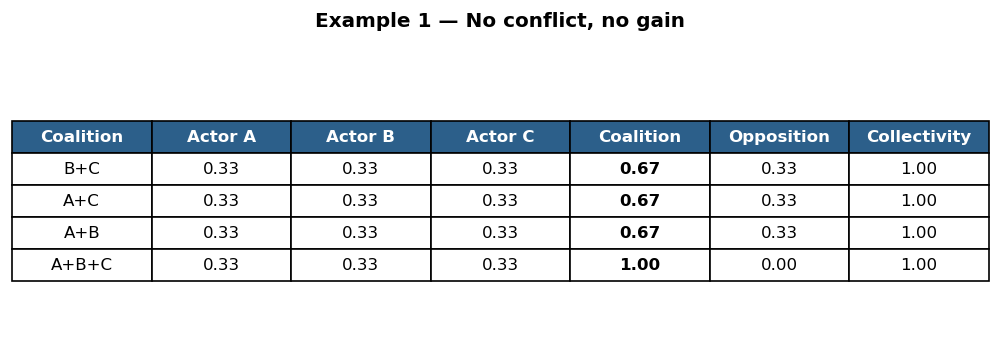

In [4]:
# Note: when all coalitions are identical, no one transitions → no sink node exists.
# This is correct: any coalition is equally good.
cc.draw_coalition_table(co1, sm1, TPM1, actor_names=list('ABC'),
                        title='Example 1 — No conflict, no gain')

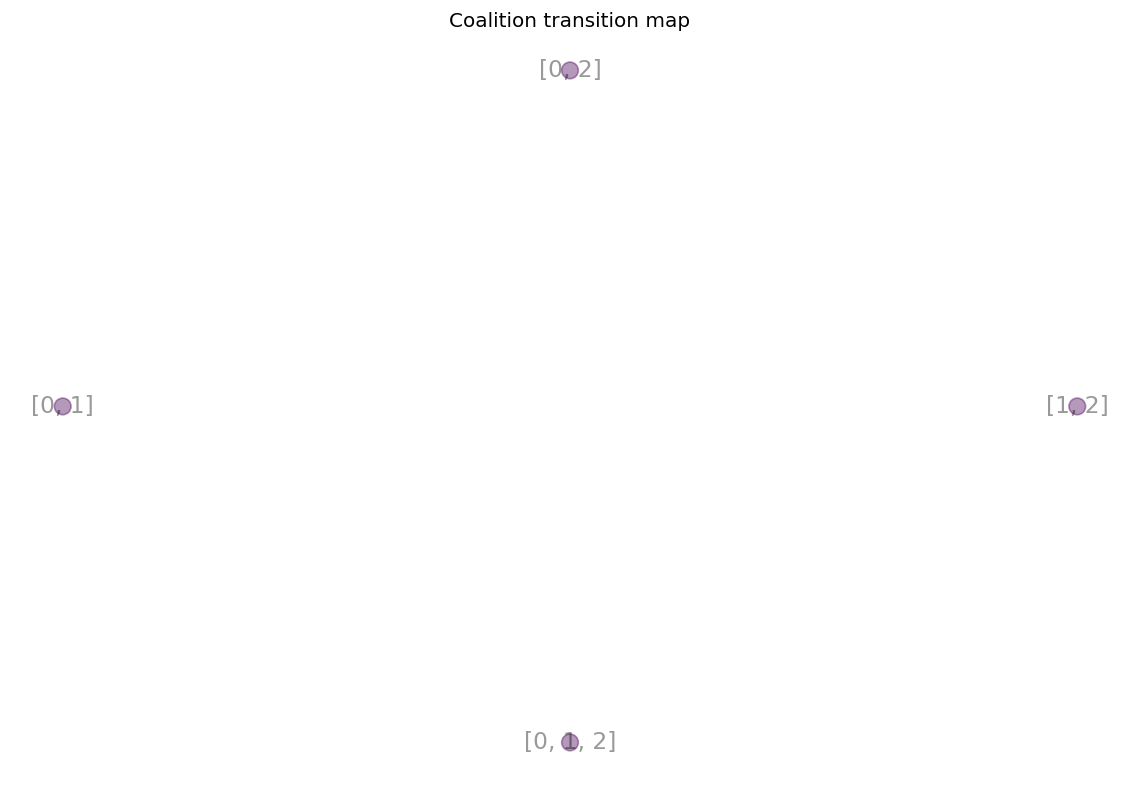

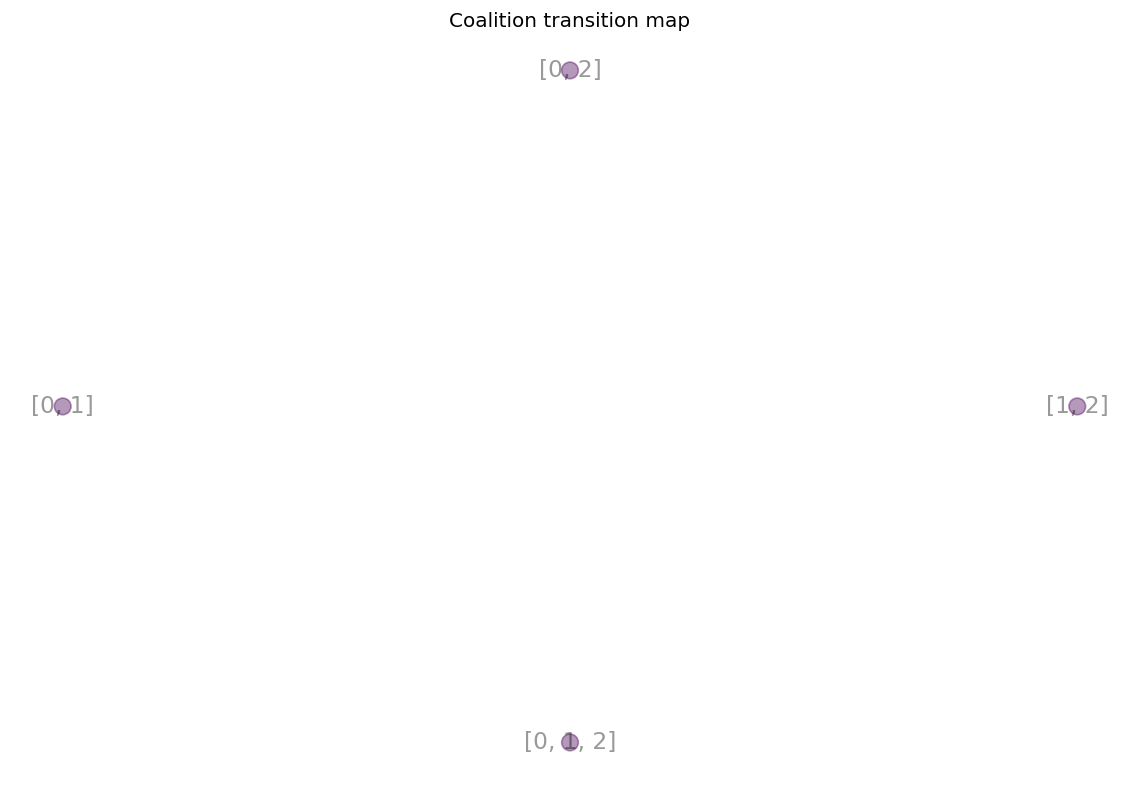

In [5]:
cc.draw_coalition_map(co1, sm1, TPM1)

---
## Example 2 — Conflicting attitudes introduce coalition benefits

Same control and interest weights as Example 1, but now the actors **disagree** on exactly one issue each:

| | Issue I | Issue II | Issue III |
|--|--|--|--|
| A | + | + | − |
| B | + | − | + |
| C | − | + | + |

Each pair agrees on exactly one issue.  By symmetry, all two-actor coalitions are equally valuable — and all beat the grand coalition.

> *Conclusion*: Any two-actor coalition is preferable; **first-movers win** because no member can be enticed to leave.

In [6]:
att2 = np.array([[+1, +1, -1],
                 [+1, -1, +1],
                 [-1, +1, +1]], dtype=float)   # issues × actors
d2 = (att2 * (1/3)).tolist()

inputs2 = make_inputs(d2, uniform_ctrl(3, 3))
co2, sm2, TPM2 = run(inputs2)

print("Winning coalitions:", winner_labels(co2, TPM2, list('ABC')))

Winning coalitions: ['B+C', 'A+C', 'A+B']


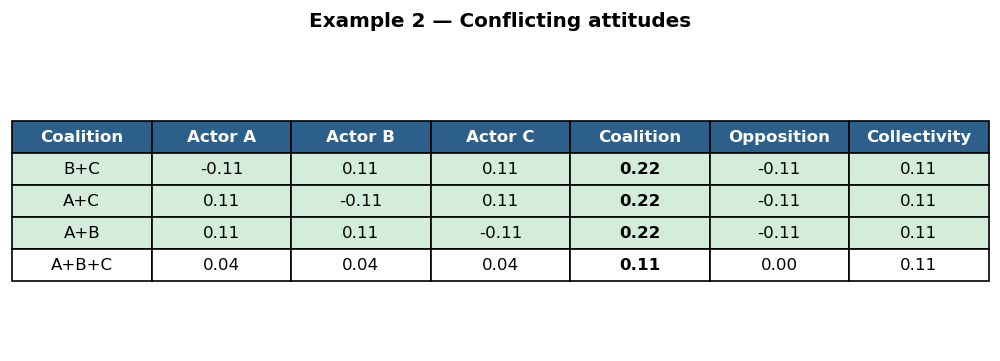

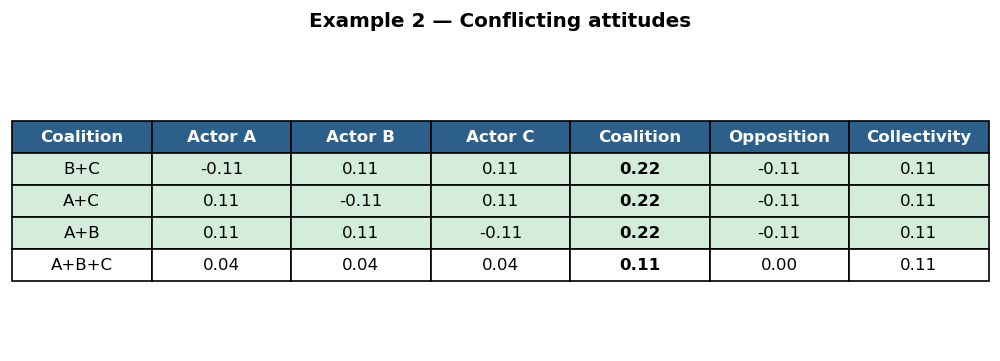

In [7]:
cc.draw_coalition_table(co2, sm2, TPM2, actor_names=list('ABC'),
                        title='Example 2 — Conflicting attitudes')

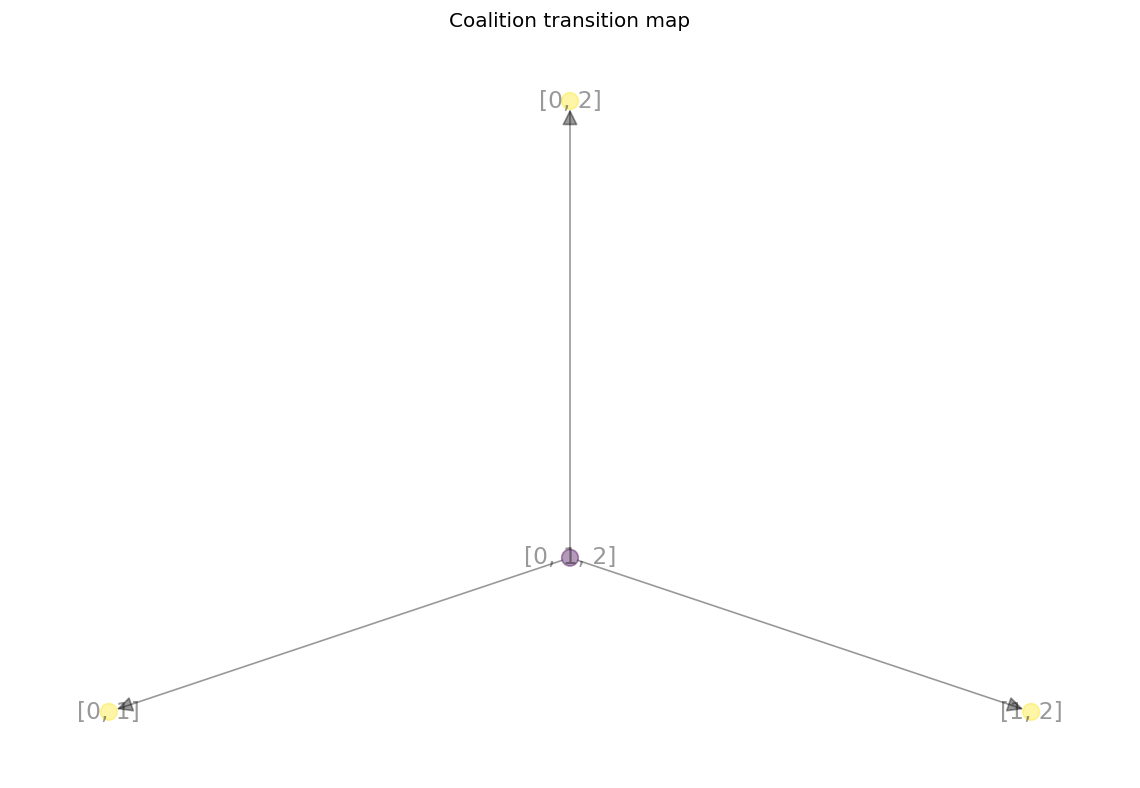

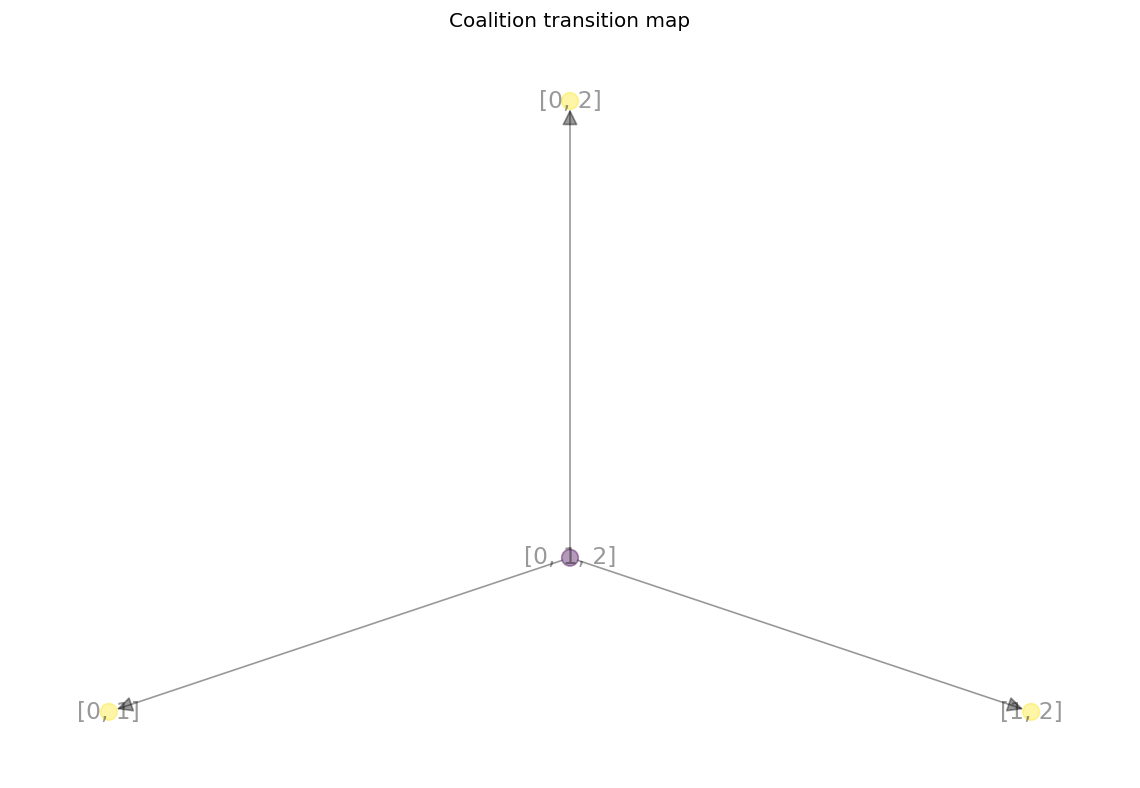

In [8]:
cc.draw_coalition_map(co2, sm2, TPM2)

---
## Example 3 — Actors agreeing on most issues form the winning coalition

Only one attitude changes from Example 2: Actor A now **opposes** Issue I as well.

| | Issue I | Issue II | Issue III |
|--|--|--|--|
| A | **−** | + | − |
| B | + | − | + |
| C | − | + | + |

Now: A & B oppose each other on **all three** issues; A & C agree on Issues I and II; B & C agree only on Issue III.

> *Conclusion*: **A+C** forms the winning coalition (agree on 2 of 3 issues).

In [9]:
att3 = np.array([[-1, +1, -1],
                 [+1, -1, +1],
                 [-1, +1, +1]], dtype=float)
d3 = (att3 * (1/3)).tolist()

inputs3 = make_inputs(d3, uniform_ctrl(3, 3))
co3, sm3, TPM3 = run(inputs3)

print("Winning coalitions:", winner_labels(co3, TPM3, list('ABC')))

Winning coalitions: ['A+C']


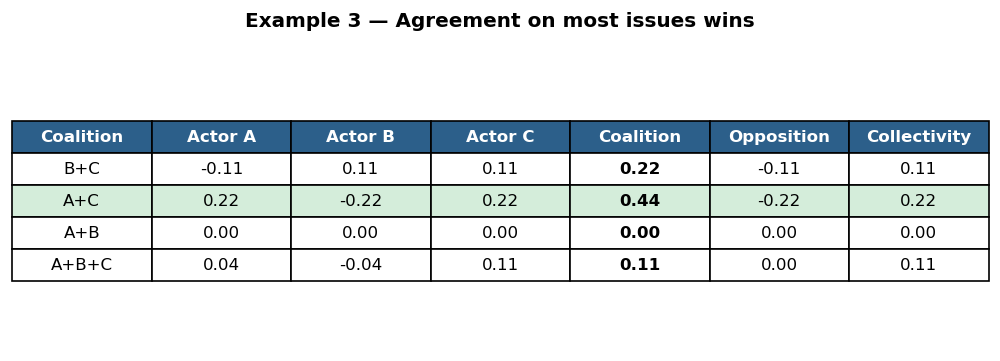

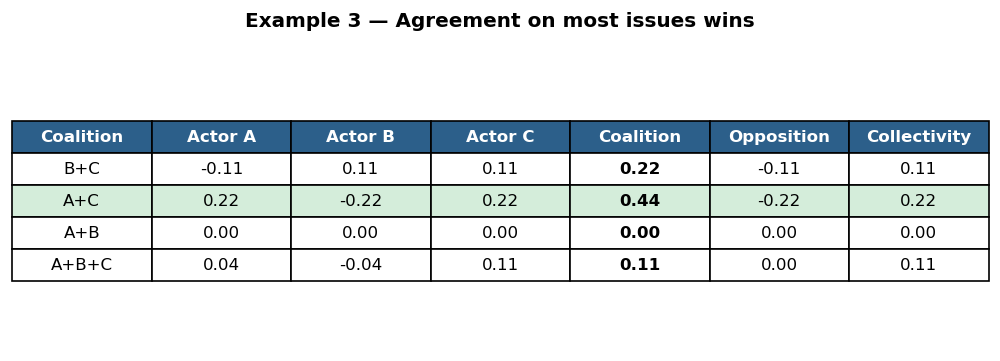

In [10]:
cc.draw_coalition_table(co3, sm3, TPM3, actor_names=list('ABC'),
                        title='Example 3 — Agreement on most issues wins')

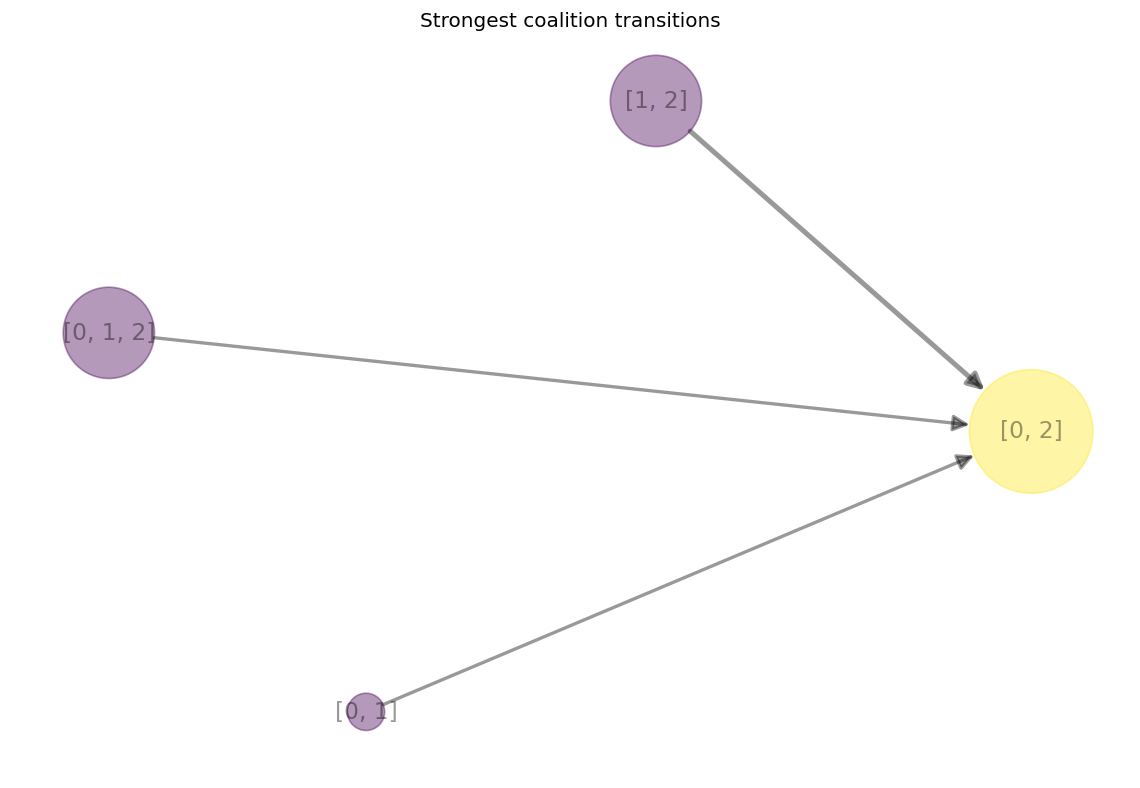

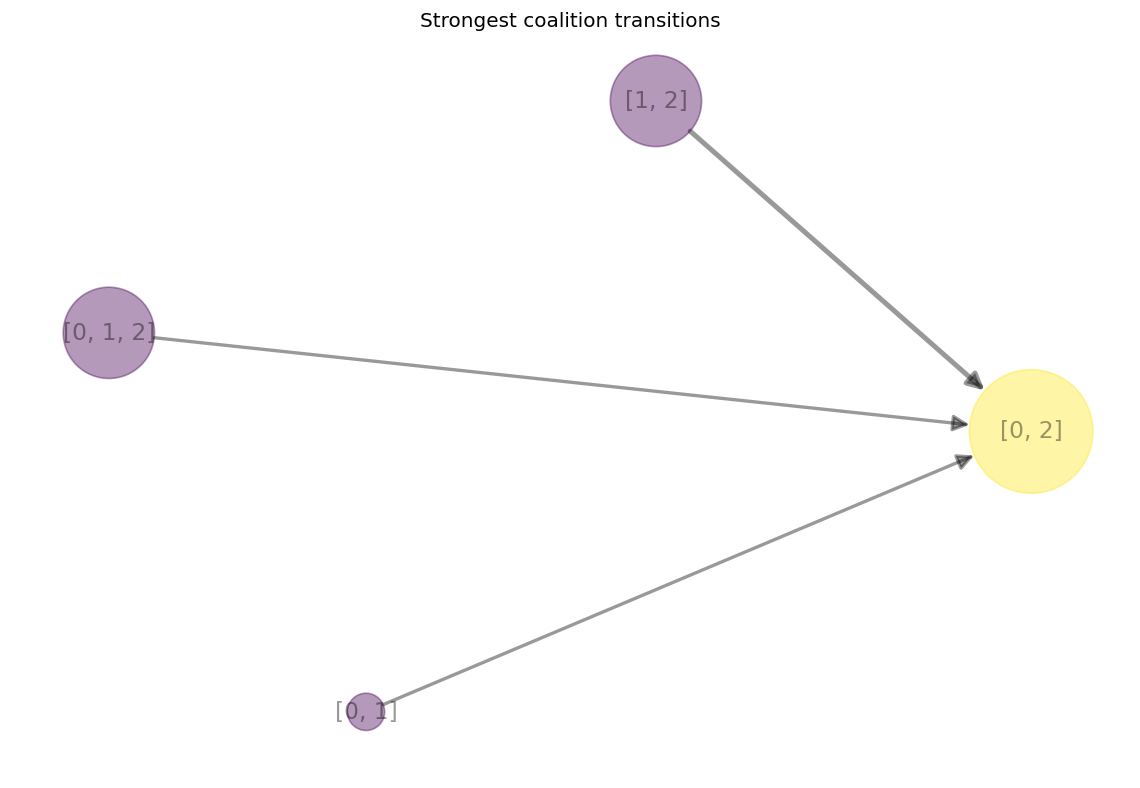

In [11]:
cc.draw_strongest_transitions(co3, sm3, TPM3)

---
## Example 4 — Interest intensity can override attitude alignment

Keep Example 3's attitudes, but give Issue III a **much higher weight** (0.70 vs 0.10 and 0.20 for Issues I–II):

| | Issue I | Issue II | Issue III |
|--|--|--|--|
| All actors | 0.10 | 0.20 | **0.70** |

B and C agree *only* on Issue III — but because it is overwhelmingly the most important issue, their coalition becomes more valuable than A+C.

> *Conclusion*: **B+C** wins.  Intensity of shared interest on a high-stakes issue can trump breadth of attitude alignment.

In [12]:
interest4 = np.array([[0.10, 0.10, 0.10],
                       [0.20, 0.20, 0.20],
                       [0.70, 0.70, 0.70]])
att3_arr = np.array([[-1, +1, -1],
                     [+1, -1, +1],
                     [-1, +1, +1]], dtype=float)
d4 = (att3_arr * interest4).tolist()

inputs4 = make_inputs(d4, uniform_ctrl(3, 3))
co4, sm4, TPM4 = run(inputs4)

print("Winning coalitions:", winner_labels(co4, TPM4, list('ABC')))

Winning coalitions: ['B+C']


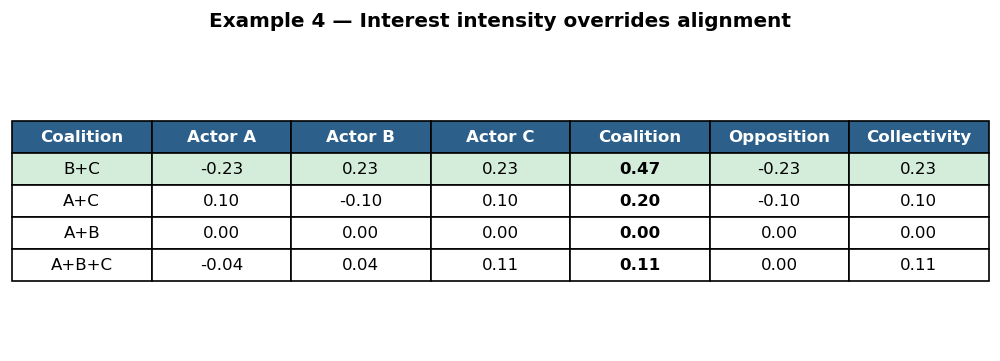

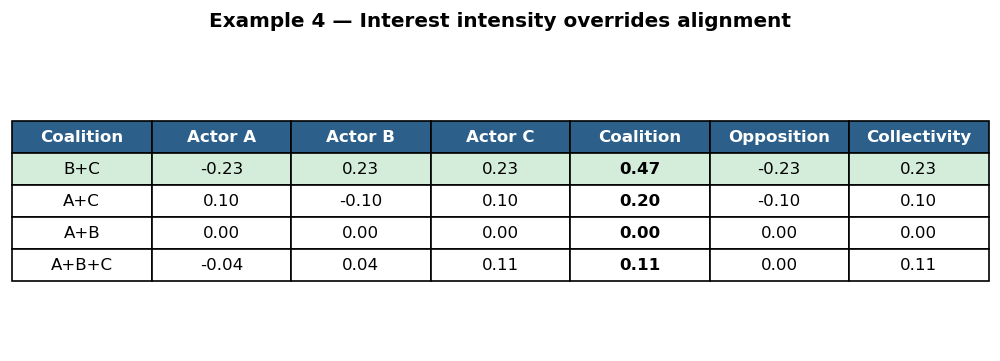

In [13]:
cc.draw_coalition_table(co4, sm4, TPM4, actor_names=list('ABC'),
                        title='Example 4 — Interest intensity overrides alignment')

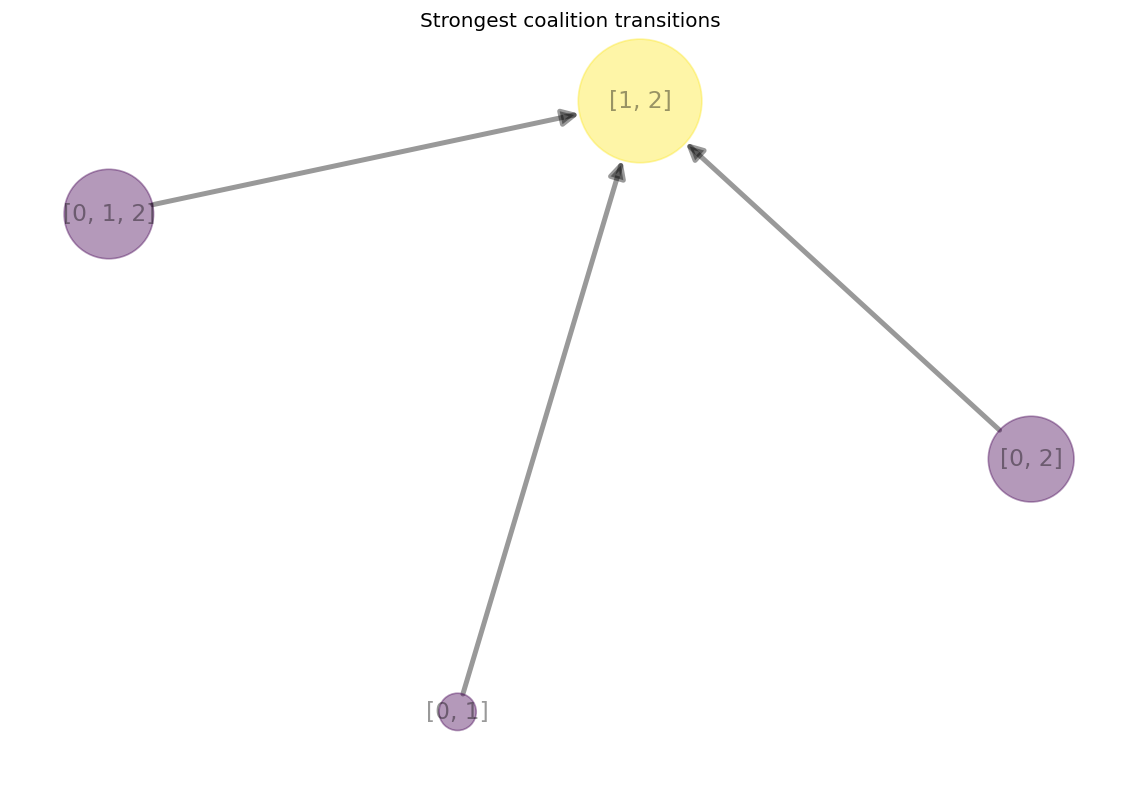

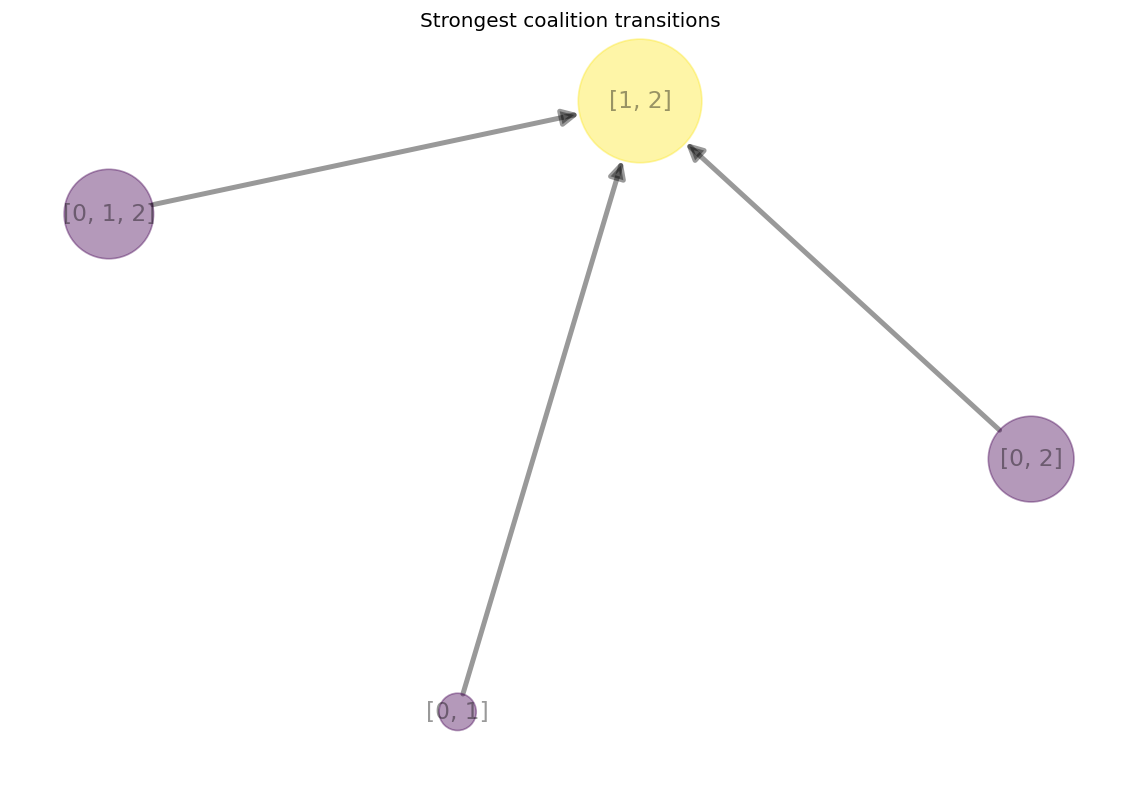

In [14]:
cc.draw_strongest_transitions(co4, sm4, TPM4)

---
## Example 5 — Cycling loop: no stable coalition

With **four actors** and randomly generated interests/control, some constellations produce a **cycle**: there is always a better alternative for at least one coalition member.

The transition graph shows a closed loop — corresponding to an Arrovian cycle in collective preferences.

In [15]:
# Directed interest matrix (Table 16 in paper), issues × actors
d5 = [[ 0.21, -0.15,  0.27, -0.49],   # Issue I
      [ 0.06, -0.44,  0.57, -0.19],   # Issue II
      [-0.73,  0.41,  0.16,  0.32]]   # Issue III

# Control matrix (Table 17): same distribution for all issues
ctrl5 = [[0.49, 0.07, 0.38, 0.06]] * 3

inputs5 = make_inputs(d5, ctrl5)
co5, sm5, TPM5 = run(inputs5)

print("Feasible coalitions:", list(co5.keys()))
print("Winning coalitions:", winner_labels(co5, TPM5, list('ABCD')) or "none (cycling loop)")

Feasible coalitions: ['[1, 2, 3]', '[0, 3]', '[0, 2]', '[0, 2, 3]', '[0, 1]', '[0, 1, 3]', '[0, 1, 2]', '[0, 1, 2, 3]']
Winning coalitions: none (cycling loop)


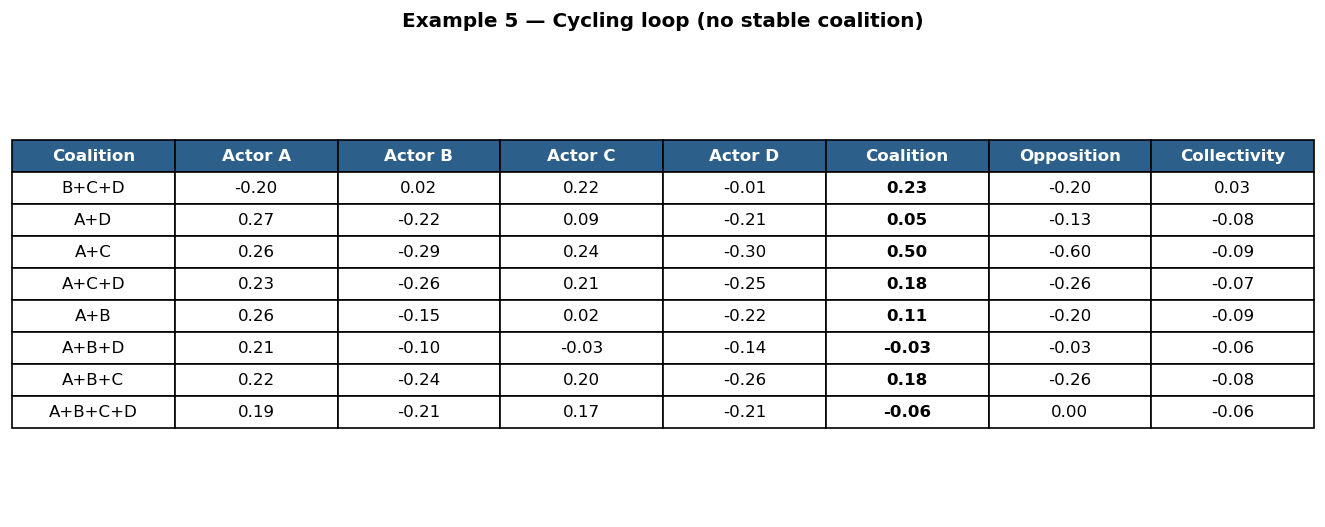

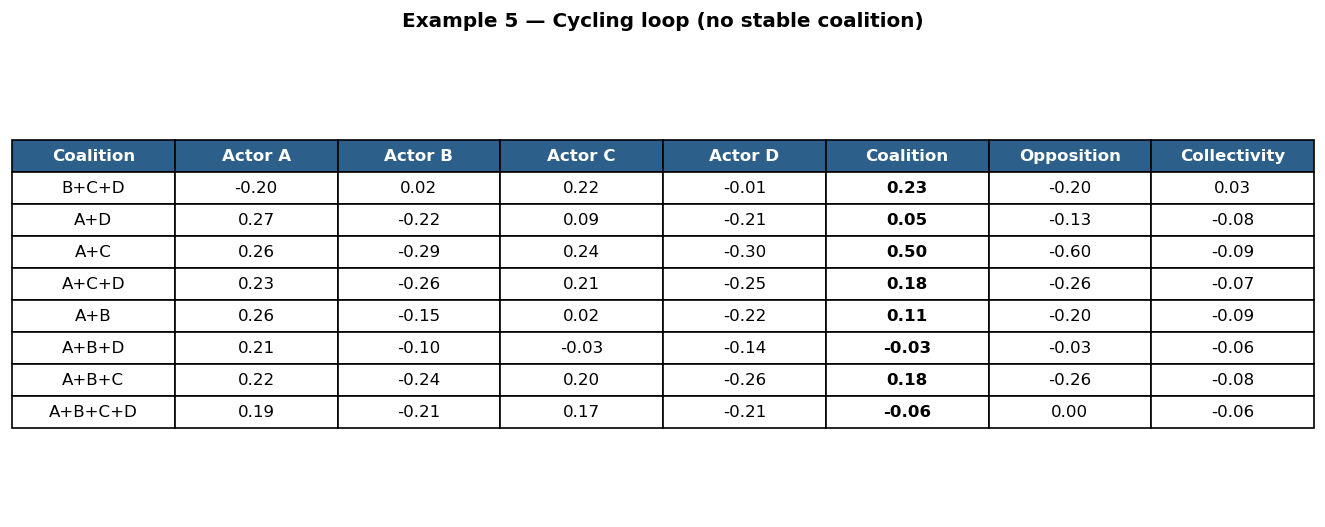

In [16]:
cc.draw_coalition_table(co5, sm5, TPM5, actor_names=list('ABCD'),
                        title='Example 5 — Cycling loop (no stable coalition)',
                        figsize=(14, 5))

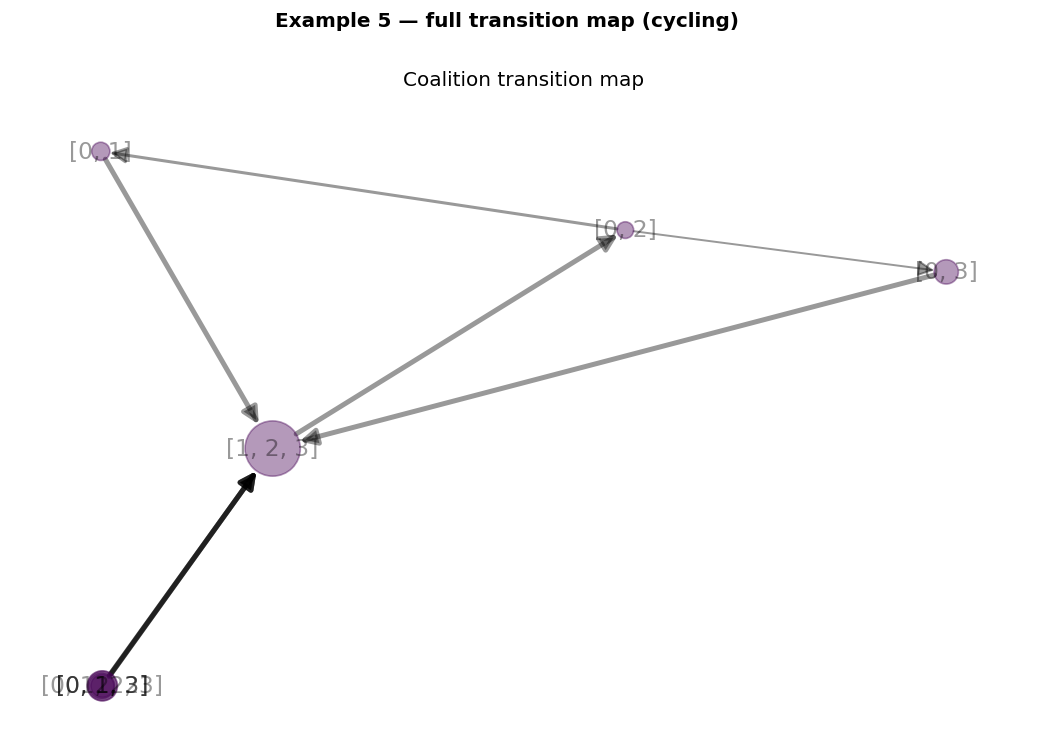

In [17]:
fig5a = cc.draw_coalition_map(co5, sm5, TPM5, figsize=(11, 7))
fig5a.suptitle('Example 5 — full transition map (cycling)', fontweight='bold')
plt.show()

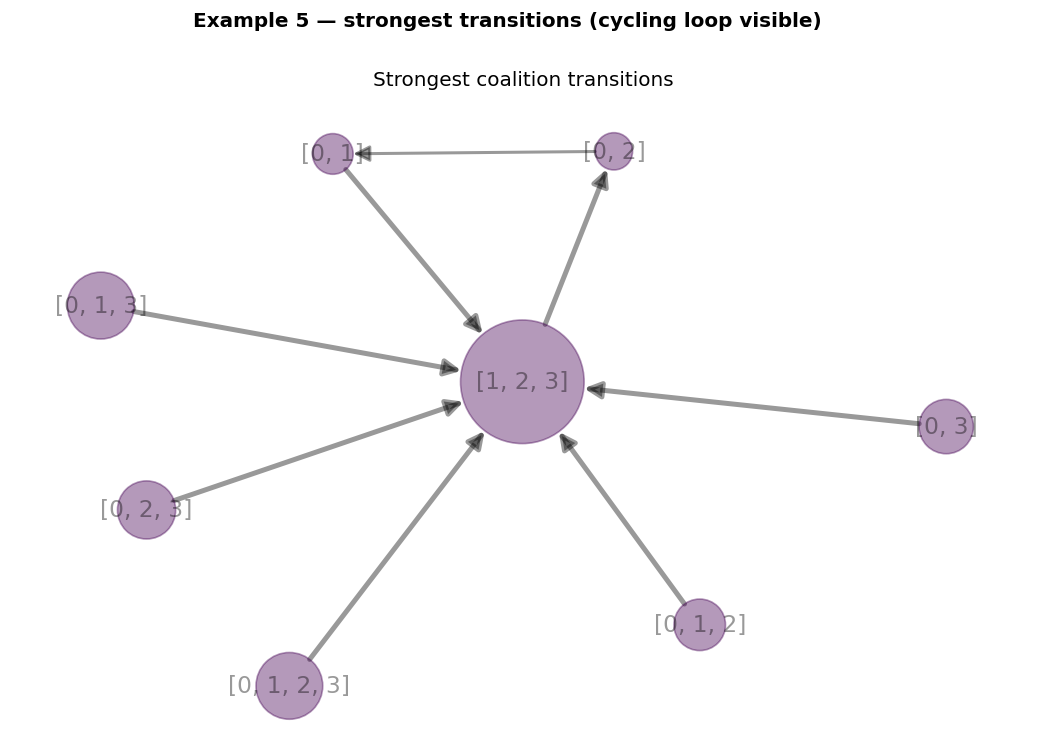

In [18]:
fig5b = cc.draw_strongest_transitions(co5, sm5, TPM5, figsize=(11, 7))
fig5b.suptitle('Example 5 — strongest transitions (cycling loop visible)', fontweight='bold')
plt.show()

---
## Example 6 — Breaking the loop by introducing a new issue

One way to resolve a cycling loop is to **introduce a new issue** on which a majority of actors agree, anchoring one coalition as the dominant option.

Here we add **Issue IV** where B, C, and D all strongly support the outcome while A opposes it.  After renormalising actor interests across all four issues, B+C+D becomes a stable winning coalition.

> *Note*: The paper leaves this as a topic for further research.  The example below is one concrete solution — other issue designs would also work.

In [19]:
# Append Issue IV to Example 5's directed interests and renormalise
d5_arr = np.array(d5)                              # (3, 4)
new_issue = np.array([[-0.50, 0.15, 0.50, 0.20]])  # A opposes, B/C/D support
d6_raw = np.vstack([d5_arr, new_issue])            # (4, 4)

# Renormalise column-wise (each actor's |interests| sum to 1)
col_abs = np.sum(np.abs(d6_raw), axis=0, keepdims=True)
d6 = (d6_raw / col_abs).tolist()

ctrl6 = [[0.49, 0.07, 0.38, 0.06]] * 4

inputs6 = make_inputs(d6, ctrl6)
co6, sm6, TPM6 = run(inputs6)

print("Winning coalitions:", winner_labels(co6, TPM6, list('ABCD')))

Winning coalitions: ['B+C+D']


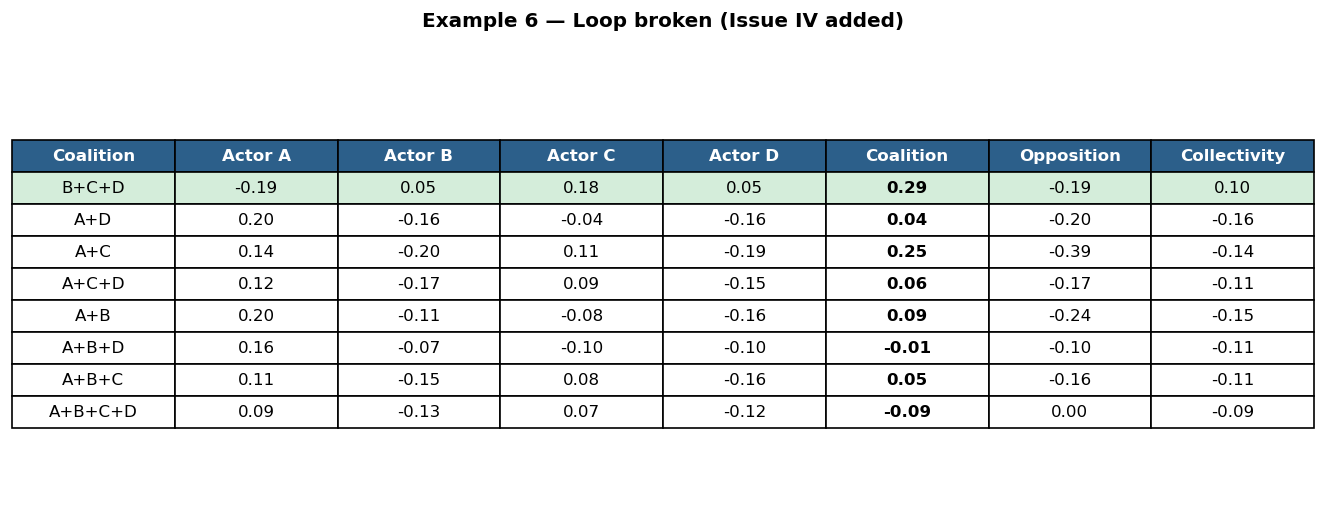

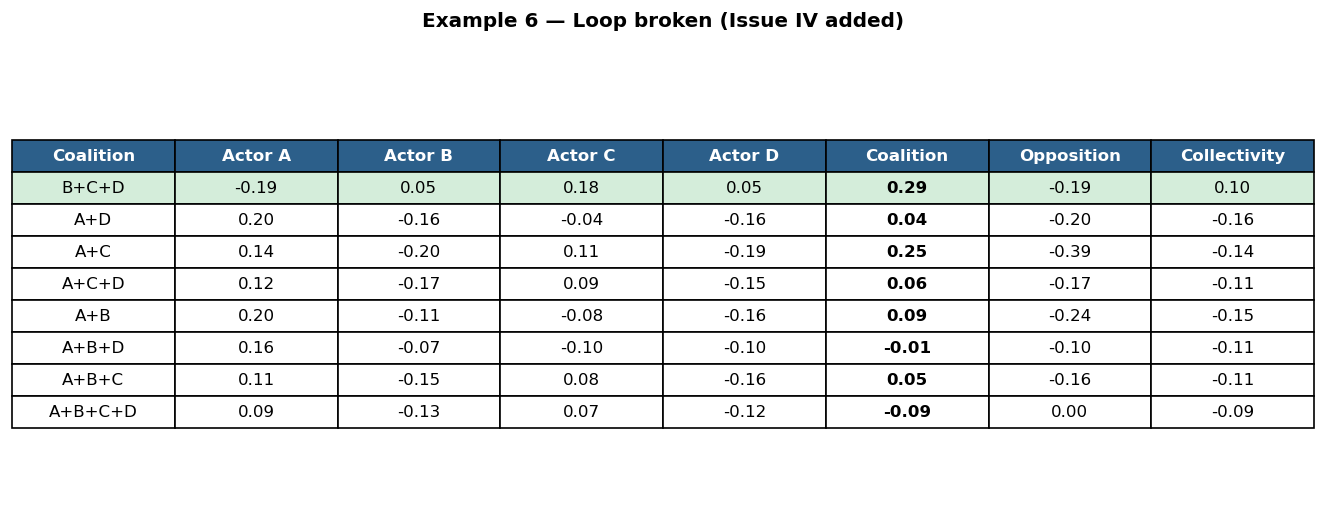

In [20]:
cc.draw_coalition_table(co6, sm6, TPM6, actor_names=list('ABCD'),
                        title='Example 6 — Loop broken (Issue IV added)',
                        figsize=(14, 5))

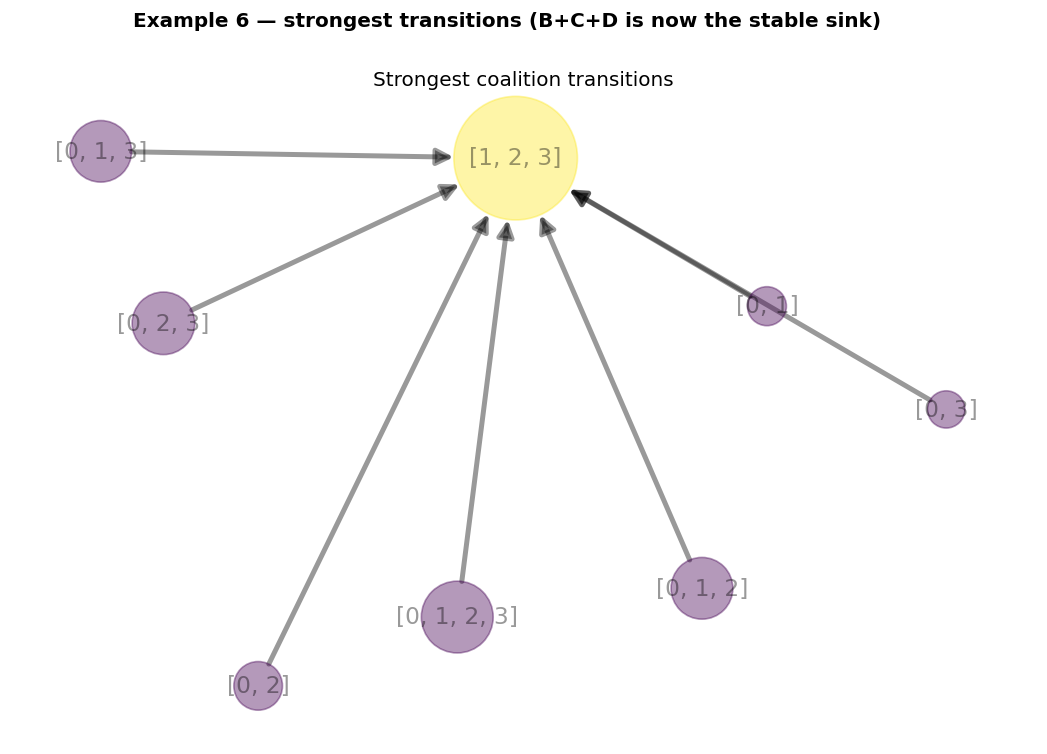

In [21]:
fig6 = cc.draw_strongest_transitions(co6, sm6, TPM6, figsize=(11, 7))
fig6.suptitle('Example 6 — strongest transitions (B+C+D is now the stable sink)',
              fontweight='bold')
plt.show()

---
## Example 7 — Path dependence: the starting point determines the winner

With four actors and a different random draw of interests/control, **two stable coalitions** coexist.  Which one emerges depends on the **starting coalition** in negotiations:

- Starting from **C+D** → path leads to **B+C+D**
- Starting from **A+C+D** → path leads to **A+B+D**

> *Conclusion*: Coalition outcomes are not deterministic — **who negotiates first matters**.

In [22]:
# Directed interest (Table 20), issues × actors
d7 = [[ 0.05,  0.24,  0.32,  0.24],   # I
      [ 0.20, -0.53, -0.23, -0.43],   # II
      [ 0.75,  0.23, -0.45,  0.32]]   # III

# Control (Table 19): same distribution for all issues
ctrl7 = [[0.33, 0.16, 0.21, 0.30]] * 3

inputs7 = make_inputs(d7, ctrl7)
co7, sm7, TPM7 = run(inputs7)

print("Feasible coalitions:", list(co7.keys()))
print("Winning coalitions:", winner_labels(co7, TPM7, list('ABCD')))

Feasible coalitions: ['[2, 3]', '[1, 2, 3]', '[0, 3]', '[0, 2]', '[0, 2, 3]', '[0, 1, 3]', '[0, 1, 2]', '[0, 1, 2, 3]']
Winning coalitions: ['B+C+D', 'A+B+D']


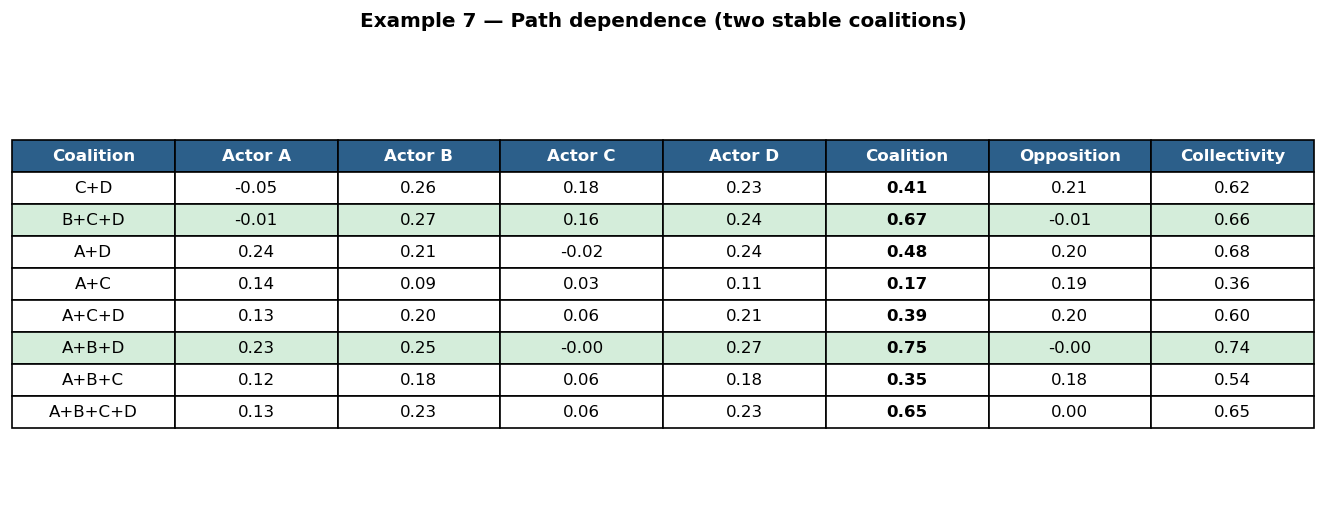

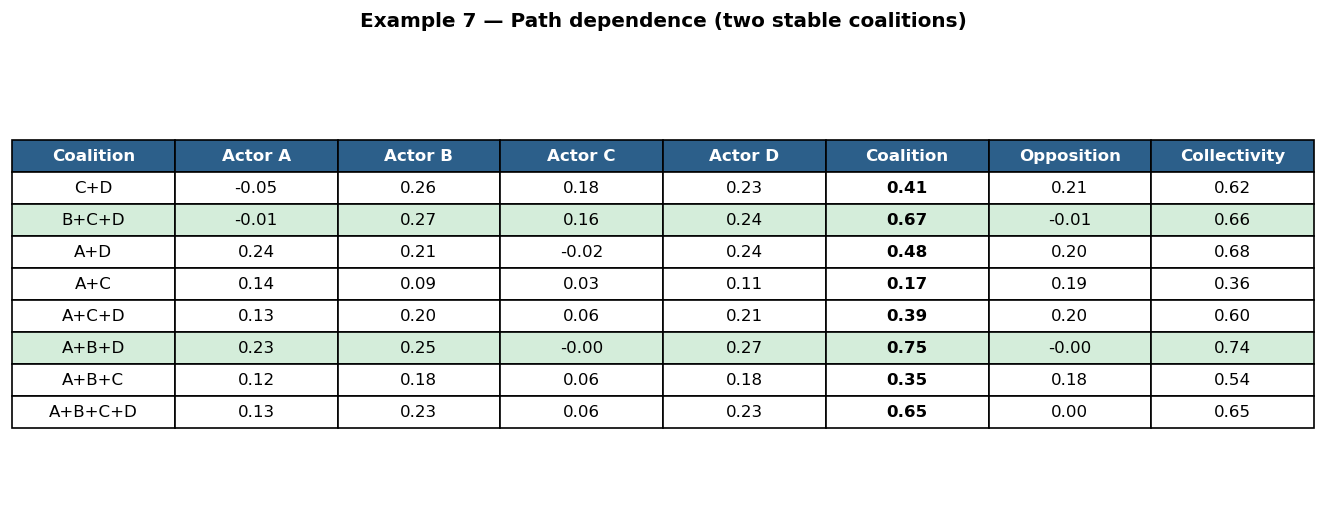

In [23]:
cc.draw_coalition_table(co7, sm7, TPM7, actor_names=list('ABCD'),
                        title='Example 7 — Path dependence (two stable coalitions)',
                        figsize=(14, 5))

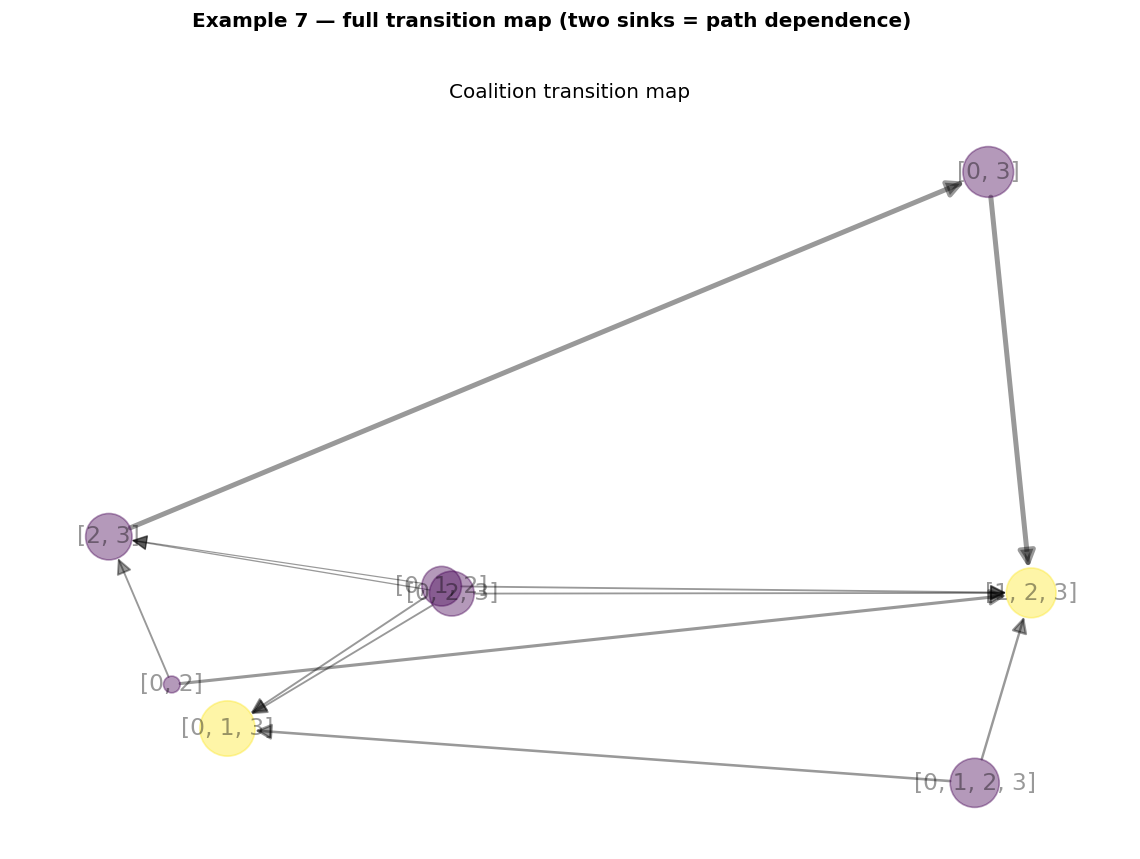

In [24]:
fig7a = cc.draw_coalition_map(co7, sm7, TPM7, figsize=(12, 8))
fig7a.suptitle('Example 7 — full transition map (two sinks = path dependence)',
               fontweight='bold')
plt.show()

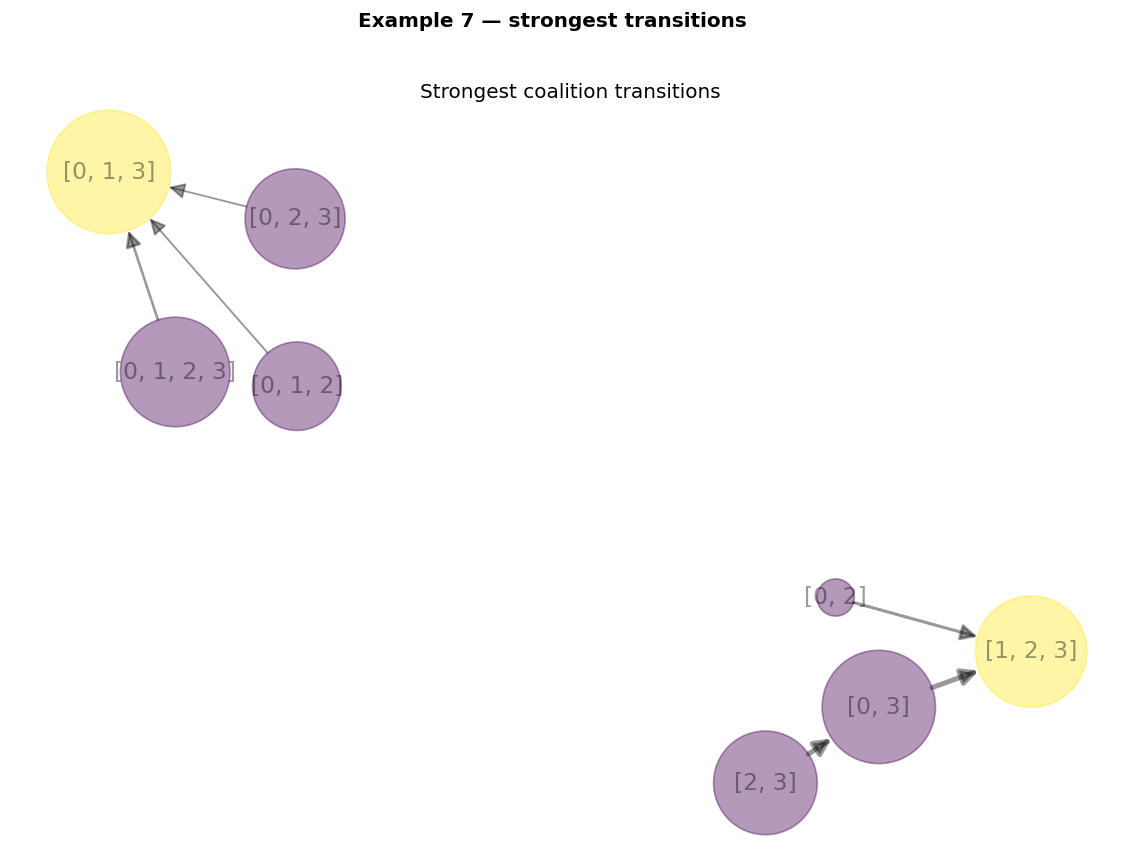

Path from C+D: C+D → A+D → B+C+D
Path from A+C+D: A+C+D → A+B+D


In [25]:
fig7b = cc.draw_strongest_transitions(co7, sm7, TPM7, figsize=(12, 8))
fig7b.suptitle('Example 7 — strongest transitions', fontweight='bold')
plt.show()

# Trace dominant paths from two starting points
names7 = list(co7.keys())
TPM7_arr = np.array(TPM7)
actor7 = list('ABCD')

def trace(start_key):
    path, current = [start_key], names7.index(start_key)
    for _ in range(20):
        row = TPM7_arr[current]
        if row.max() == 0:
            break
        nxt = int(row.argmax())
        if names7[nxt] in path:
            break
        path.append(names7[nxt]); current = nxt
    return ['+'.join(actor7[i] for i in ast.literal_eval(k)) for k in path]

for key, label in [('[2, 3]', 'C+D'), ('[0, 2, 3]', 'A+C+D')]:
    if key in names7:
        print(f"Path from {label}:", ' → '.join(trace(key)))

---
## Example 8 — Min-winning coalition not always optimal (5 actors, Monte Carlo)

From a Wikipedia article on Riker, a five-actor example has control:

| A | B | C | D | E |
|---|---|---|---|---|
| 0.05 | 0.40 | 0.26 | 0.25 | 0.04 |

Riker's size principle predicts **C+D** (the minimum winning coalition at 51%) will dominate.  
We run **1 000 simulations** with randomly drawn interest/attitude matrices and record which coalition wins each time.

In [26]:
ctrl8_row = [0.05, 0.40, 0.26, 0.25, 0.04]
ctrl8 = [ctrl8_row] * 3    # 3 issues
n8, q8 = 5, 3
actor8 = list('ABCDE')

win_counts8 = {}
n_conv8 = 0

for _ in range(1_000):
    raw = RNG.uniform(-1, 1, size=(q8, n8))
    col_abs = np.sum(np.abs(raw), axis=0, keepdims=True)
    col_abs[col_abs == 0] = 1
    y_ia = (raw / col_abs).tolist()
    try:
        inp = make_inputs(y_ia, ctrl8)
        co, sm, TPM = run(inp)
        for key, w in zip(co.keys(), cc.winning_coalitions(TPM)):
            if w:
                lbl = '+'.join(actor8[i] for i in ast.literal_eval(key))
                win_counts8[lbl] = win_counts8.get(lbl, 0) + 1
        n_conv8 += 1
    except Exception:
        pass

print(f"Converged: {n_conv8}/1000")
top8 = sorted(win_counts8, key=lambda k: -win_counts8[k])[:10]
print("Top coalitions:", {k: win_counts8[k] for k in top8})

Converged: 1000/1000
Top coalitions: {'C+D': 349, 'B+D': 341, 'B+C': 299, 'C+D+E': 107, 'A+C+D': 90, 'B+D+E': 90, 'B+C+E': 79, 'A+B+D': 76, 'A+B+C': 75, 'A+C+D+E': 27}


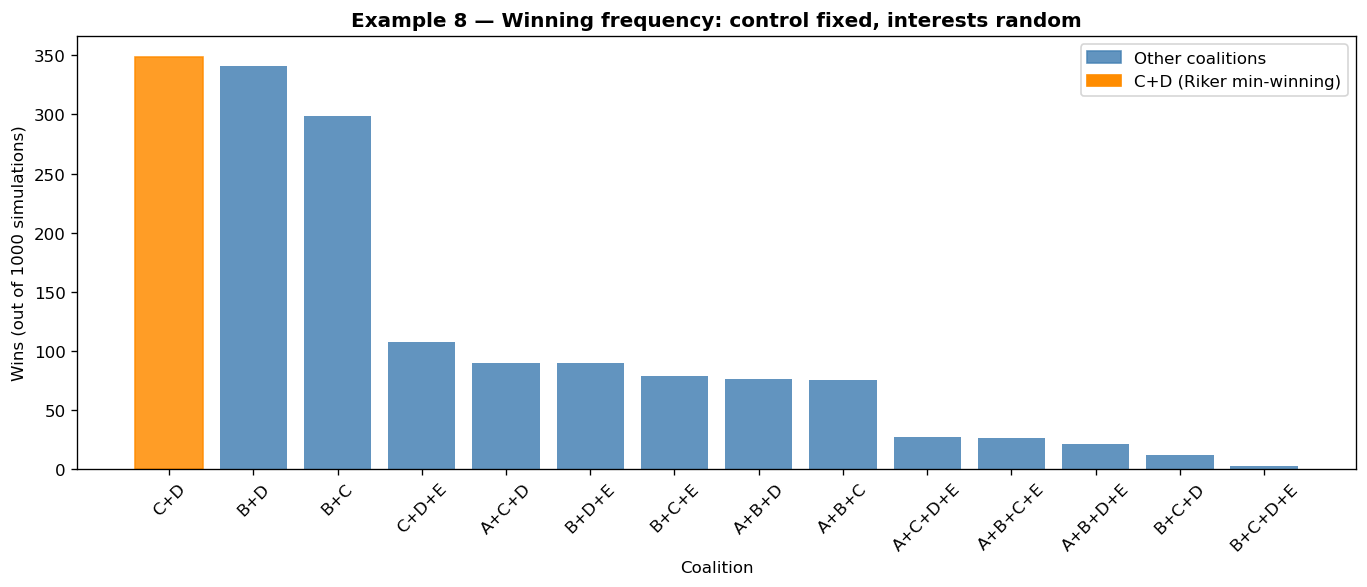

In [27]:
labels8 = sorted(win_counts8, key=lambda k: -win_counts8[k])
counts8 = [win_counts8[k] for k in labels8]

fig, ax = plt.subplots(figsize=(max(8, len(labels8) * 0.75 + 1), 5))
bars = ax.bar(labels8, counts8, color='steelblue', alpha=0.85)
for bar, lbl in zip(bars, labels8):
    if lbl == 'C+D':
        bar.set_color('darkorange')
ax.set_xlabel('Coalition')
ax.set_ylabel(f'Wins (out of {n_conv8} simulations)')
ax.set_title('Example 8 — Winning frequency: control fixed, interests random',
             fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend(handles=[
    mpatches.Patch(color='steelblue',   alpha=0.85, label='Other coalitions'),
    mpatches.Patch(color='darkorange',             label='C+D (Riker min-winning)'),
])
fig.tight_layout()
plt.show()

> **C+D wins only ~35% of simulations** — far from dominant.  Taking attitudes and interest intensity into account substantially alters predictions relative to Riker's size principle.

---
## Example 9 — Varying control, fixed interests (4 actors, Monte Carlo)

Now we fix the **directed interest** matrix (Table 23 in the draft) and run **1 000 simulations** in which each actor's control over each issue is drawn randomly.

| | A | B | C | D |
|--|--|--|--|--|
| Issue I   | +0.10 | −0.22 | −0.13 | +0.09 |
| Issue II  | +0.20 | +0.33 | −0.25 | +0.09 |
| Issue III | −0.20 | −0.11 | +0.38 | −0.27 |
| Issue IV  | −0.10 | +0.11 | +0.13 | +0.18 |
| Issue V   | +0.40 | +0.22 | +0.13 | +0.36 |

In [28]:
# Fixed directed interest (Table 23), issues × actors
d9 = [[ 0.10, -0.22, -0.13,  0.09],
      [ 0.20,  0.33, -0.25,  0.09],
      [-0.20, -0.11,  0.38, -0.27],
      [-0.10,  0.11,  0.13,  0.18],
      [ 0.40,  0.22,  0.13,  0.36]]

n9, q9 = 4, 5
actor9 = list('ABCD')

win_counts9 = {}
n_conv9 = 0

for _ in range(1_000):
    raw_ctrl = RNG.uniform(0, 1, size=(q9, n9))
    c_rand = (raw_ctrl / raw_ctrl.sum(axis=1, keepdims=True)).tolist()
    try:
        inp = make_inputs(d9, c_rand)
        co, sm, TPM = run(inp)
        for key, w in zip(co.keys(), cc.winning_coalitions(TPM)):
            if w:
                lbl = '+'.join(actor9[i] for i in ast.literal_eval(key))
                win_counts9[lbl] = win_counts9.get(lbl, 0) + 1
        n_conv9 += 1
    except Exception:
        pass

print(f"Converged: {n_conv9}/1000")
print("Win counts:", dict(sorted(win_counts9.items(), key=lambda x: -x[1])))

Converged: 1000/1000
Win counts: {'B+D': 426, 'A+D': 337, 'A+B+D': 129, 'A+B': 120, 'B+C': 42, 'C+D': 8, 'B+C+D': 2}


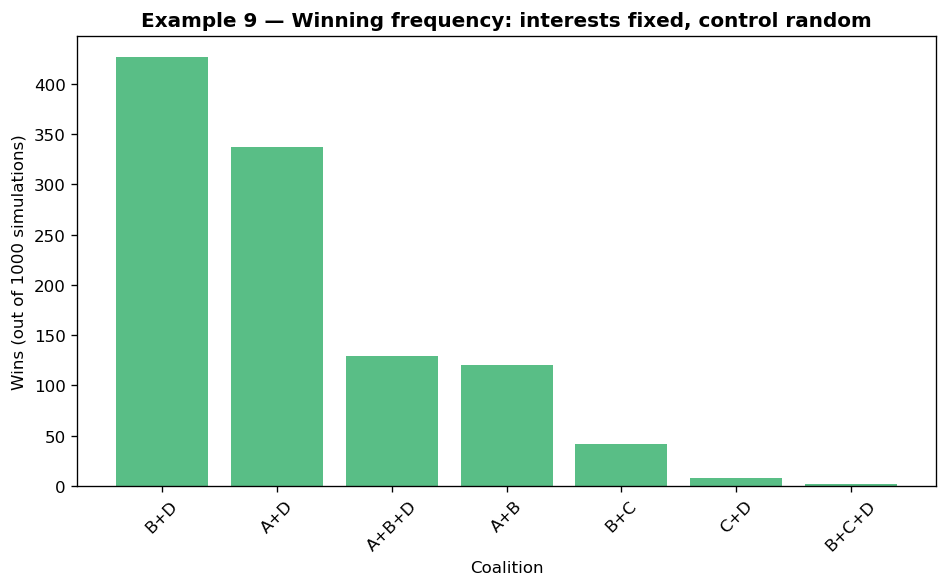

In [29]:
labels9 = sorted(win_counts9, key=lambda k: -win_counts9[k])
counts9 = [win_counts9[k] for k in labels9]

fig, ax = plt.subplots(figsize=(max(8, len(labels9) * 0.75 + 1), 5))
ax.bar(labels9, counts9, color='mediumseagreen', alpha=0.85)
ax.set_xlabel('Coalition')
ax.set_ylabel(f'Wins (out of {n_conv9} simulations)')
ax.set_title('Example 9 — Winning frequency: interests fixed, control random',
             fontweight='bold')
ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
plt.show()

> **B+D and A+D dominate** across control draws — driven by their strong alignment on Issue V (the highest-weighted issue for A and B).  Control distribution matters, but the pattern of winners is already largely set by the fixed interest/attitude structure.

---
## Summary

| Example | Key finding |
|---------|-------------|
| 1 | Fully aligned actors gain nothing from coalitions |
| 2 | Any two-actor coalition beats the grand coalition; first movers win |
| 3 | Actors agreeing on more issues form the winning coalition (A+C) |
| 4 | High intensity on one issue can override alignment breadth (B+C wins) |
| 5 | Some interest/control constellations produce a cycling loop (no stable equilibrium) |
| 6 | A new issue can break the loop by anchoring one coalition |
| 7 | Two stable sinks coexist — the outcome depends on the starting coalition |
| 8 | The Riker min-winning coalition (C+D) wins only ~35% of 1 000 simulations |
| 9 | Varying control changes who wins, but the interest structure remains decisive |

**General conclusion**: A realistic model of coalition formation must incorporate not just *how much control* each actor has, but also *which direction* and *with what intensity* their interests are directed.